# Statisitsche Auswertung des Experiments

### Preprocessing

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import os
import json
import sys

In [43]:
RESULTS_DIR = "../results/"
TABLES_DIR = "./tables/"
FIGURES_DIR = "./figures/"

for directory in [TABLES_DIR, FIGURES_DIR]:
    os.makedirs(directory, exist_ok=True)

In [44]:
def load_and_preprocess_data(filepath):
    df = pd.read_csv(filepath)
    df["all_tokens"] = df["all_tokens"].fillna(df["input_tokens"] + df["output_tokens"])
    return df

In [45]:
df_A_gemini = load_and_preprocess_data("../results/experiment_benchmark_A_all_20260708_144919.csv")

df_A_gemini.head()

,condition,complexity,doc_id,f1_exact,prec_exact,rec_exact,f1_substring,prec_substring,rec_substring,f1_fuzzy,prec_fuzzy,rec_fuzzy,is_hallucination,is_numeric_hallucination,is_text_hallucination,input_tokens,output_tokens,all_tokens,retries_used,duration_seconds,match_results_fields,match_results_line_items,ground_truth,predicted,model,status,error_message
0,C1,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667,0.8000,0.8889,0.7273,False,False,False,0,0,0.0,0,0.001,"{""advertiser"": {""exact"": ""FN"", ""substring"": ""F...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""advertiser"": """", ""agency"": ""BRD 5126/ECR2680...",gemini-2.5-flash,OK,NaN
1,C2,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.6667,0.5000,1.0000,0.6667,0.5000,1.0000,0.8000,0.6667,1.0000,False,False,False,1769,645,2414.0,0,4.110,"{""advertiser"": {""exact"": ""FP_EXTRACTION_ERROR""...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [{""program_start_date"": ""02/26/...",gemini-2.5-flash,OK,NaN
2,C3,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.8571,0.7500,1.0000,0.8571,0.7500,1.0000,0.8571,0.7500,1.0000,False,False,False,5259,1556,6815.0,0,7.453,"{""advertiser"": {""exact"": ""TP"", ""substring"": ""T...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [{""program_start_date"": ""02/26/...",gemini-2.5-flash,OK,NaN
3,C4,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.4000,0.5000,0.3333,0.5000,0.6667,0.4000,0.4000,0.5000,0.3333,False,False,False,143802,266530,410332.0,3,1027.647,"{""advertiser"": {""exact"": ""TP"", ""substring"": ""T...","{""exact"": {""tp"": 0, ""fp"": 0, ""fn"": 5}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [], ""advertiser"": ""Friends of J...",gemini-2.5-flash,OK,NaN
4,C1,L1,63ad699d-fa76-17bb-1bc5-ab2fafd0a2a3.pdf,0.1176,0.1111,0.1250,0.2222,0.2222,0.2222,0.2222,0.2222,0.2222,True,True,False,0,0,0.0,0,0.002,"{""advertiser"": {""exact"": ""FP_EXTRACTION_ERROR""...","{""exact"": {""tp"": 0, ""fp"": 4, ""fn"": 3}, ""substr...","{""contract_num"": ""4339717"", ""flight_from"": ""05...","{""advertiser"": ""Entered By Grand Total: 4 $900...",gemini-2.5-flash,OK,NaN


In [46]:
df_A_gemini.columns

Index(['condition', 'complexity', 'doc_id', 'f1_exact', 'prec_exact',
       'rec_exact', 'f1_substring', 'prec_substring', 'rec_substring',
       'f1_fuzzy', 'prec_fuzzy', 'rec_fuzzy', 'is_hallucination',
       'is_numeric_hallucination', 'is_text_hallucination', 'input_tokens',
       'output_tokens', 'all_tokens', 'retries_used', 'duration_seconds',
       'match_results_fields', 'match_results_line_items', 'ground_truth',
       'predicted', 'model', 'status', 'error_message'],
      dtype='str')

In [47]:
df_A_gemini.status.value_counts()

status
OK    300
Name: count, dtype: int64

## Deskreptive Statsitik

### Funktionen

In [48]:
def export_summary_table(df, group_cols, metrics, filename):
    summary = df.groupby(group_cols)[metrics].agg(["mean", "median", "std"])

    formatted_summary = pd.DataFrame(index=summary.index)
    for metric in metrics:
        m = summary[metric]["mean"]
        s = summary[metric]["std"]
        mdn = summary[metric]["median"]

        formatted_summary[f"{metric}_M_SD"] = [
            f"{m_val:.3f} ({s_val:.3f})" for m_val, s_val in zip(m, s)
        ]
        formatted_summary[f"{metric}_Mdn"] = mdn.values

    formatted_summary.to_csv(
        os.path.join(TABLES_DIR, filename), index=True, sep=";", decimal=","
    )
    return formatted_summary

In [49]:
def plot_metric_by_complexity(df, y_metric, ylabel, filename, plot_type="bar"):
    fig, ax = plt.subplots(figsize=(10, 6))

    if plot_type == "bar":
        sns.barplot(
            data=df,
            x="complexity",
            y=y_metric,
            hue="condition",
            ax=ax,
            palette="Blues_d",
            errorbar=None,
        )
    elif plot_type == "violin":
        df_plot = (
            df[df["condition"] != "C1"]
            if "token" in y_metric or "duration" in y_metric
            else df
        )
        sns.boxplot(
            data=df_plot,
            x="complexity",
            y=y_metric,
            hue="condition",
            ax=ax,
            cut=0,
        )

    ax.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, filename))
    plt.close(fig)

### F1 Score, Recall und Precision

In [50]:
aggs = ["mean", "median", "std"]

In [51]:
f1_metrics = [
    "f1_exact",
    "prec_exact",
    "rec_exact",
    "f1_fuzzy",
    "prec_fuzzy",
    "rec_fuzzy",
    "f1_substring",
    "prec_substring",
    "rec_substring",
]

metrics_table = df_A_gemini.groupby("complexity")[f1_metrics].agg(aggs)

metrics_table.columns = [f"{col}_{stat}" for col, stat in metrics_table.columns]

# Tabelle abrunden für bessere Lesbarkeit
metrics_table = metrics_table.round(4)
display(metrics_table)

,f1_exact_mean,f1_exact_median,f1_exact_std,prec_exact_mean,prec_exact_median,prec_exact_std,rec_exact_mean,rec_exact_median,rec_exact_std,f1_fuzzy_mean,f1_fuzzy_median,f1_fuzzy_std,prec_fuzzy_mean,prec_fuzzy_median,prec_fuzzy_std,rec_fuzzy_mean,rec_fuzzy_median,rec_fuzzy_std,f1_substring_mean,f1_substring_median,f1_substring_std,prec_substring_mean,prec_substring_median,prec_substring_std,rec_substring_mean,rec_substring_median,rec_substring_std
complexity,,,,,,,,,,,,,,,,,,,,,,,,,,,
L1,0.5816,0.6667,0.2633,0.5507,0.6000,0.2483,0.6394,0.7000,0.2946,0.6344,0.7030,0.2585,0.6097,0.6667,0.2471,0.6888,0.7500,0.2912,0.6431,0.7059,0.2434,0.6338,0.7143,0.2387,0.6890,0.7136,0.2764
L2,0.2639,0.1791,0.2759,0.2335,0.1521,0.2410,0.3222,0.2222,0.3433,0.3465,0.2222,0.3046,0.3099,0.2072,0.2728,0.4209,0.3000,0.3725,0.4539,0.5728,0.3403,0.4023,0.4286,0.3084,0.5528,0.7687,0.4132
L3,0.1626,0.0204,0.2912,0.1515,0.0197,0.2689,0.1843,0.0204,0.3291,0.2046,0.0398,0.3132,0.1889,0.0364,0.2886,0.2329,0.0354,0.3538,0.2668,0.0359,0.3710,0.2466,0.0351,0.3409,0.3002,0.0342,0.4158


In [52]:
metrics_table_large = df_A_gemini.groupby(["complexity", "condition"])[f1_metrics].agg(
    aggs
)

metrics_table_large = metrics_table_large.sort_index(axis=1)

metrics_table_large = metrics_table_large.round(4)

display(metrics_table_large)

f1_exact                  ... rec_substring                
                         mean  median     std  ...          mean  median     std
complexity condition                           ...                              
L1         C1          0.2499  0.2500  0.1496  ...        0.3471  0.3333  0.1488
           C2          0.6876  0.6667  0.2069  ...        0.8170  0.8889  0.2180
           C3          0.7002  0.6957  0.1902  ...        0.8504  0.8889  0.1460
           C4          0.6886  0.7143  0.1780  ...        0.7415  0.8000  0.2354
L2         C1          0.0426  0.0357  0.0449  ...        0.0546  0.0500  0.0550
           C2          0.3240  0.2667  0.2665  ...        0.8206  0.9000  0.2582
           C3          0.3401  0.2273  0.2612  ...        0.7469  0.8333  0.2911
           C4          0.3489  0.2222  0.3232  ...        0.5892  0.8235  0.4195
L3         C1          0.0126  0.0000  0.0251  ...        0.0159  0.0000  0.0310
           C2          0.2966  0.0656  0.3513  ...        0.5260  0.8286  0.4480
           C3          0.2351  0.0588  0.3436  ...        0.4844  0.4643  0.4462
           C4          0.1063  0.0000  0.2384  ...        0.1743  0.0000  0.3513

[12 rows x 27 columns]

In [53]:
export_summary_table(
    df_A_gemini, ["condition", "complexity"], f1_metrics, "f1_precision_recall_summary.csv"
)

f1_exact_M_SD  ...  rec_substring_Mdn
condition complexity                 ...                   
C1        L1          0.250 (0.150)  ...             0.3333
          L2          0.043 (0.045)  ...             0.0500
          L3          0.013 (0.025)  ...             0.0000
C2        L1          0.688 (0.207)  ...             0.8889
          L2          0.324 (0.267)  ...             0.9000
          L3          0.297 (0.351)  ...             0.8286
C3        L1          0.700 (0.190)  ...             0.8889
          L2          0.340 (0.261)  ...             0.8333
          L3          0.235 (0.344)  ...             0.4643
C4        L1          0.689 (0.178)  ...             0.8000
          L2          0.349 (0.323)  ...             0.8235
          L3          0.106 (0.238)  ...             0.0000

[12 rows x 18 columns]

In [54]:
# overall f1_exact plot
plot_metric_by_complexity(
    df_A_gemini, "f1_exact", "F1 Exact Score", "f1_exact_bar.png", plot_type="bar"
)

In [55]:

metrics = [
    "prec_exact",
    "rec_exact",
    "f1_substring",
    "prec_substring",
    "rec_substring",
    "f1_fuzzy",
    "prec_fuzzy",
    "rec_fuzzy",
    "is_hallucination",
    "is_numeric_hallucination",
    "is_text_hallucination",
    "input_tokens",
    "output_tokens",
    "all_tokens",
    "duration_seconds",
]

for metric in metrics:
    plot_metric_by_complexity(df_A_gemini, metric, f"{metric} Score0", f"{metric}_bar.png", plot_type="bar")

In [56]:
f1_data = metrics_table_large["f1_exact"][["mean", "std"]]

f1_data_formatted = f1_data.apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})".replace(".", ","), axis=1
)

df_result = f1_data_formatted.unstack(level="complexity")

total = df_A_gemini.groupby("condition")["f1_exact"].agg(["mean", "std"])
df_result["Total"] = total.apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})".replace(".", ","),
    axis=1,
)

df_result = df_result[["L1", "L2", "L3", "Total"]]
df_result.index = [
    "C1: RPA",
    "C2: Single-Prompt",
    "C3: Single-Agent",
    "C4: Multi-Agent",
]
df_result.rename_axis("Architekturen", axis=1, inplace=True)

display(df_result)
df_result.to_csv("./tables/f1_exact_summary.csv", index=True, sep=";", decimal=",")

Architekturen,L1,L2,L3,Total
C1: RPA,"0,250 (0,150)","0,043 (0,045)","0,013 (0,025)","0,102 (0,139)"
C2: Single-Prompt,"0,688 (0,207)","0,324 (0,267)","0,297 (0,351)","0,436 (0,330)"
C3: Single-Agent,"0,700 (0,190)","0,340 (0,261)","0,235 (0,344)","0,425 (0,335)"
C4: Multi-Agent,"0,689 (0,178)","0,349 (0,323)","0,106 (0,238)","0,381 (0,347)"


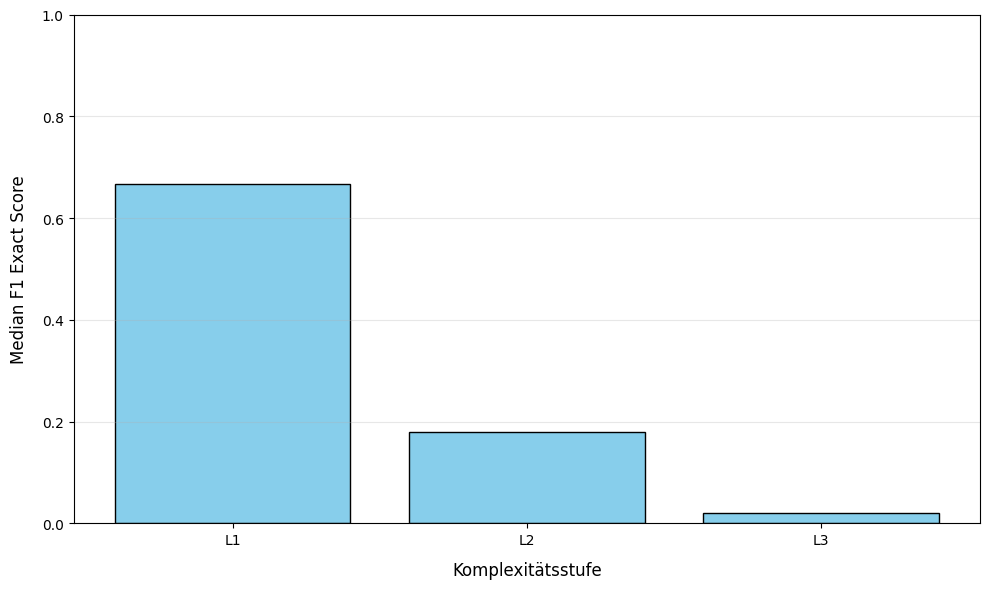

In [57]:
median_scores = df_A_gemini.groupby("complexity")["f1_exact"].median()

labels = median_scores.index.tolist()
medians = median_scores.values

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(labels, medians, color="skyblue", edgecolor="black")

ax.set_xlabel("Komplexitätsstufe", fontsize=12, labelpad=10)
ax.set_ylabel("Median F1 Exact Score", fontsize=12, labelpad=10)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./figures/f1_exact_bar_chart_overall.png")
plt.show()

In [58]:
prec_recall_exact = df_A_gemini.groupby(["complexity", "condition"])[["prec_exact", "rec_exact"]].agg(["mean", "std"])

prec_recall_exact_formatted = pd.DataFrame()

for metric in ["prec_exact", "rec_exact"]:
    formatted = prec_recall_exact[metric].apply(
        lambda row: f"{row['mean']:.3f} ({row['std']:.3f})".replace(".", ","), axis=1
    )
    prec_recall_exact_formatted[metric] = formatted

prec_recall_table = prec_recall_exact_formatted.unstack(level="complexity")
prec_recall_table = prec_recall_table.swaplevel(axis=1).sort_index(axis=1)

prec_recall_table.index = [
    "C1: RPA",
    "C2: Single-Prompt",
    "C3: Single-Agent",
    "C4: Multi-Agent",
]
prec_recall_table.rename_axis([None, "Architekturen"], axis=1, inplace=True)

display(prec_recall_table)

prec_recall_table.to_csv(
    "./tables/precision_recall_summary.csv", index=True, sep=";", decimal=","
)

L1                 ...             L3               
Architekturen         prec_exact      rec_exact  ...     prec_exact      rec_exact
C1: RPA            0,258 (0,173)  0,266 (0,155)  ...  0,012 (0,023)  0,014 (0,031)
C2: Single-Prompt  0,619 (0,207)  0,787 (0,212)  ...  0,267 (0,325)  0,351 (0,409)
C3: Single-Agent   0,638 (0,189)  0,787 (0,193)  ...  0,221 (0,326)  0,255 (0,368)
C4: Multi-Agent    0,687 (0,157)  0,717 (0,236)  ...  0,106 (0,212)  0,118 (0,273)

[4 rows x 6 columns]

In [59]:
df_filtered_C1 = df_A_gemini[df_A_gemini["condition"] != "C1"]

### Halluzinationen

In [60]:
df_hallucination = df_filtered_C1[
    [
        "condition",
        "complexity",
        "doc_id",
        "is_hallucination",
        "is_numeric_hallucination",
        "is_text_hallucination",
    ]
].copy()

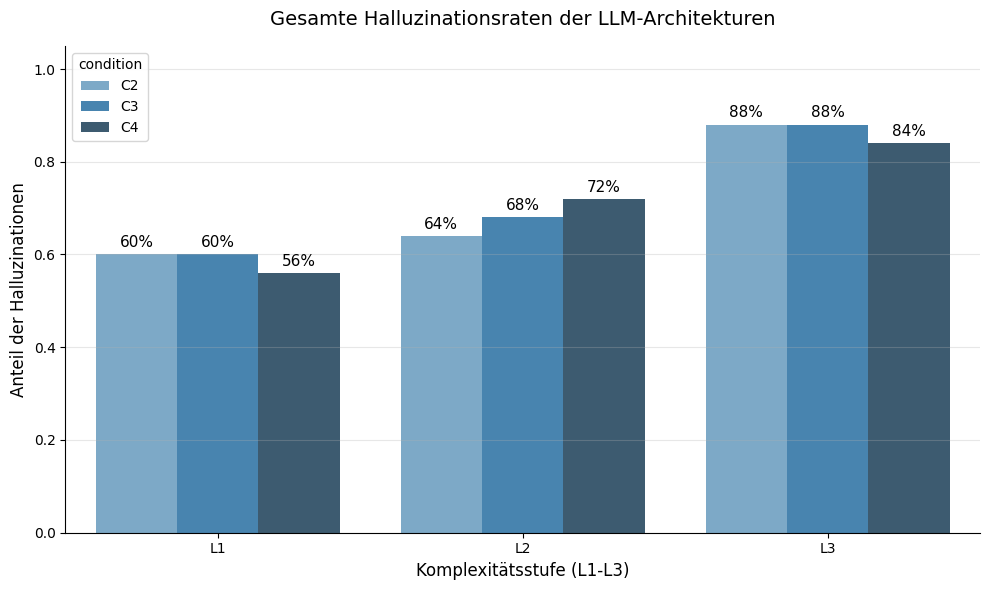

In [61]:

df_hallucination["is_hallucination"] = df_hallucination["is_hallucination"].astype(int)
df_hallucination["is_numeric_hallucination"] = df_hallucination["is_numeric_hallucination"].astype(int)
df_hallucination["is_text_hallucination"] = df_hallucination["is_text_hallucination"].astype(int)

df_hallucination["text_only_hallucination"] = (
    (df_hallucination["is_text_hallucination"] == 1) & 
    (df_hallucination["is_numeric_hallucination"] == 0)
).astype(int)

fig1, ax1 = plt.subplots(figsize=(10, 6))
plot1 = sns.barplot(
    data=df_hallucination,
    x="complexity",
    y="is_hallucination",
    hue="condition",
    ax=ax1,
    palette="Blues_d",
    errorbar=None,
)

for container in plot1.containers:
    plot1.bar_label(
        container, 
        fmt=lambda x: f'{x*100:.0f}%', 
        label_type='edge', 
        padding=3, 
        fontsize=11
    )

ax1.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
ax1.set_ylabel("Anteil der Halluzinationen", fontsize=12)
ax1.set_title("Gesamte Halluzinationsraten der LLM-Architekturen", fontsize=14, pad=15)
ax1.set_ylim(0, 1.05)
ax1.grid(axis="y", alpha=0.3)
sns.despine()

plt.tight_layout()
fig1.savefig(os.path.join(FIGURES_DIR, "is_hallucination_bar_C2-C4.png"), dpi=300)
plt.show()

In [62]:
df_hallucination.head()

,condition,complexity,doc_id,is_hallucination,is_numeric_hallucination,is_text_hallucination,text_only_hallucination
1,C2,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0,0,0,0
2,C3,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0,0,0,0
3,C4,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0,0,0,0
5,C2,L1,63ad699d-fa76-17bb-1bc5-ab2fafd0a2a3.pdf,1,1,0,0
6,C3,L1,63ad699d-fa76-17bb-1bc5-ab2fafd0a2a3.pdf,1,1,0,0


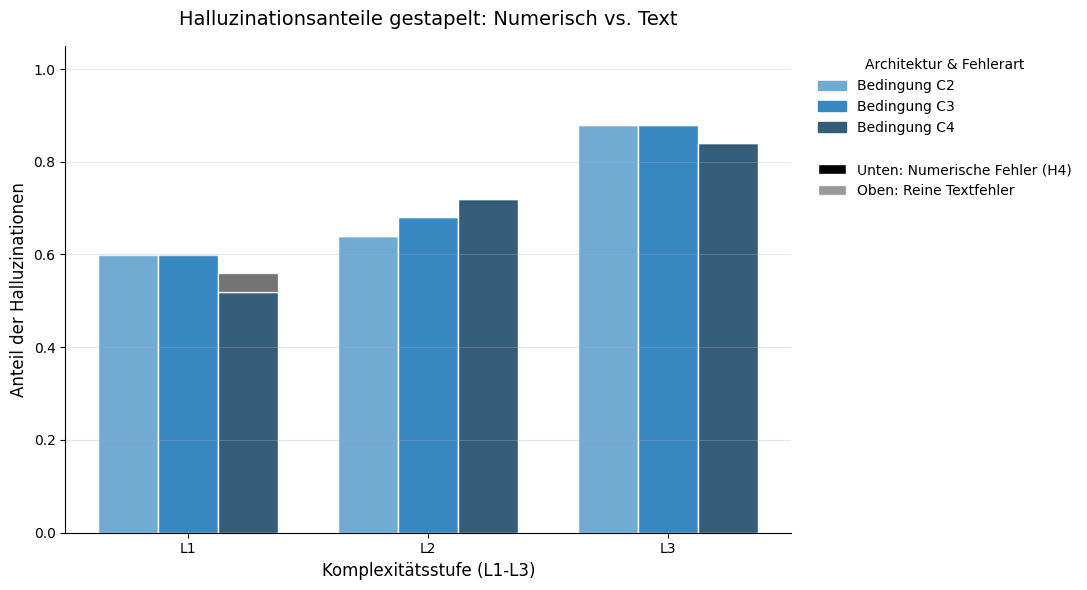

In [63]:
import matplotlib.patches as mpatches

grouped_hallucination = (
    df_hallucination.groupby(["complexity", "condition"])[
        ["is_numeric_hallucination", "text_only_hallucination"]
    ]
    .mean()
    .reset_index()
)

fig2, ax2 = plt.subplots(
    figsize=(11, 6)
) 

complexities = grouped_hallucination["complexity"].unique()
conditions = grouped_hallucination["condition"].unique()

x = np.arange(len(complexities))
width = 0.25 
offsets = [-width, 0, width] 

colors_num = sns.color_palette("Blues_d", len(conditions))
colors_text = sns.color_palette("Greys", len(conditions))

for i, cond in enumerate(conditions):
    cond_data = grouped_hallucination[grouped_hallucination["condition"] == cond]

    ax2.bar(
        x + offsets[i],
        cond_data["is_numeric_hallucination"],
        width,
        color=colors_num[i],
        edgecolor="white",
    )

    # Top-Balken: Reine Text-Halluzinationen
    ax2.bar(
        x + offsets[i],
        cond_data["text_only_hallucination"],
        width,
        bottom=cond_data["is_numeric_hallucination"],
        color=colors_text[i],
        edgecolor="white",
        alpha=0.8,
    )

ax2.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
ax2.set_ylabel("Anteil der Halluzinationen", fontsize=12)
ax2.set_title(
    "Halluzinationsanteile gestapelt: Numerisch vs. Text", fontsize=14, pad=15
)
ax2.set_xticks(x)
ax2.set_xticklabels(complexities)
ax2.set_ylim(0, 1.05)
ax2.grid(axis="y", alpha=0.3)

arch_patches = [
    mpatches.Patch(color=colors_num[i], label=f"Bedingung {cond}")
    for i, cond in enumerate(conditions)
]

type_patches = [
    mpatches.Patch(
        facecolor="none", edgecolor="none", label=""
    ),  # Unsichtbarer Spacer für die Optik
    mpatches.Patch(
        facecolor="black", edgecolor="white", label="Unten: Numerische Fehler (H4)"
    ),
    mpatches.Patch(
        facecolor="grey", alpha=0.8, edgecolor="white", label="Oben: Reine Textfehler"
    ),
]

ax2.legend(
    handles=arch_patches + type_patches,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    title="Architektur & Fehlerart",
    frameon=False,
)

sns.despine()
plt.tight_layout()

# Speichern und Anzeigen
# fig2.savefig(os.path.join(FIGURES_DIR, "is_hallucination_stacked_C2-C4.png"), dpi=300)
plt.show()

In [64]:
plot_metric_by_complexity(
    df_filtered_C1,
    "is_hallucination",
    ylabel="Anteil der Halluzinationen",
    filename="is_hallucination_bar_C2-C4.png",
    plot_type="bar",
)

### Tokenverbrauch pro Architektur

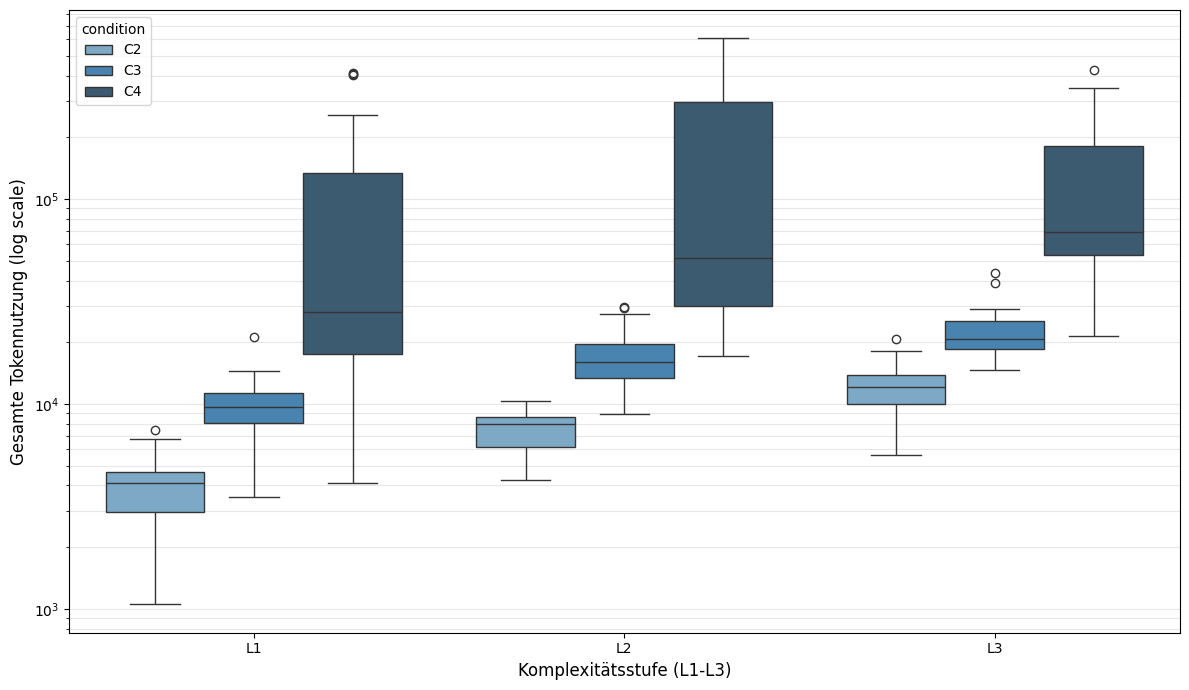

In [65]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_filtered_C1,
    x="complexity",
    y="all_tokens",
    hue="condition",
    ax=ax,
    palette="Blues_d",
)

# Logarithmische Skalierung aktivieren
ax.set_yscale("log")

ax.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
ax.set_ylabel("Gesamte Tokennutzung (log scale)", fontsize=12)

ax.grid(True, which="both", axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "total_token_usage_log.png"), dpi=300)
plt.show(fig)

In [66]:
df_A_gemini["all_tokens"] = df_A_gemini["all_tokens"].where(
    df_A_gemini["all_tokens"].notnull(),
    df_A_gemini["input_tokens"] + df_A_gemini["output_tokens"],
)

all_tokens_summary = df_A_gemini.groupby("complexity")["all_tokens"].agg(
    ["mean", "median", "std"]
).round(2)

display(all_tokens_summary)

all_tokens_summary_large = df_A_gemini.groupby(["complexity", "condition"])["all_tokens"].agg(
    aggs
).round(2)

display(all_tokens_summary_large)

,mean,median,std
complexity,,,
L1,28367.04,6553.5,79114.93
L2,48182.82,9511.0,113583.14
L3,39187.90,16450.5,72467.58


mean   median        std
complexity condition                               
L1         C1              0.00      0.0       0.00
           C2           4020.08   4097.0    1569.98
           C3           9968.76   9678.0    3389.40
           C4          99479.32  28230.0  136854.59
L2         C1              0.00      0.0       0.00
           C2           7557.84   7992.0    1614.66
           C3          17354.84  16084.0    5855.75
           C4         167818.60  51349.0  182054.23
L3         C1              0.00      0.0       0.00
           C2          12114.80  12059.0    3640.96
           C3          22517.24  20837.0    6975.47
           C4         122119.56  68989.0  108553.41

In [67]:
df_filtered = df_A_gemini[df_A_gemini["condition"] != "C1"].copy()

df_filtered["all_tokens"] = df_filtered["all_tokens"].where(
    df_filtered["all_tokens"].notnull(),
    df_filtered["input_tokens"] + df_filtered["output_tokens"],
)

aggs = ["mean", "std", "median"]
final_table_tokens = (
    df_filtered.groupby(["condition", "complexity"])["all_tokens"].agg(aggs).round(2)
)
final_table_tokens["M (SD)"] = final_table_tokens.apply(
    lambda row: f"{row['mean']:,.2f} ({row['std']:,.2f})".replace(",", "X")
    .replace(".", ",")
    .replace("X", "."),
    axis=1,
)

final_table_tokens = final_table_tokens[["M (SD)", "median"]].rename(
    columns={"median": "Mdn"}
)
final_table_tokens.index.names = ["Condition", "Complexity"]
final_table_tokens.columns.name = ""

display(final_table_tokens)
final_table_tokens.to_csv("./tables/tokens_summary.csv", index=True, sep=";", decimal=",")

M (SD)      Mdn
Condition Complexity                                  
C2        L1              4.020,08 (1.569,98)   4097.0
          L2              7.557,84 (1.614,66)   7992.0
          L3             12.114,80 (3.640,96)  12059.0
C3        L1              9.968,76 (3.389,40)   9678.0
          L2             17.354,84 (5.855,75)  16084.0
          L3             22.517,24 (6.975,47)  20837.0
C4        L1           99.479,32 (136.854,59)  28230.0
          L2          167.818,60 (182.054,23)  51349.0
          L3          122.119,56 (108.553,41)  68989.0

### Time-to-Completion in Sekunden

In [68]:
all_time_summary = (
    df_A_gemini.groupby("complexity")["duration_seconds"]
    .agg(["mean", "median", "std"])
    .round(4)
)

display(all_time_summary)

all_time_summary_large = (
    df_A_gemini.groupby(["complexity", "condition"])["duration_seconds"]
    .agg(aggs)
    .round(4)
)

display(all_time_summary_large)

,mean,median,std
complexity,,,
L1,64.3472,7.8405,195.3080
L2,108.9002,13.1195,285.7027
L3,77.9402,24.5605,174.7378


mean       std   median
complexity condition                             
L1         C1           0.0021    0.0015    0.002
           C2           7.4182    4.5111    6.093
           C3           9.7285    3.8683    9.607
           C4         240.2400  338.0681   63.381
L2         C1           0.0032    0.0015    0.003
           C2          13.3283    4.7923   11.698
           C3          20.1972   11.6207   14.686
           C4         402.0720  465.7843   91.113
L3         C1           0.0041    0.0024    0.003
           C2          24.0260   10.7894   22.678
           C3          27.9142    9.1044   25.191
           C4         259.8167  281.6581  127.910

In [69]:
formatted = all_time_summary_large[["mean", "std"]].apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})".replace(".", ","), axis=1
)
total_stats = df_A_gemini.groupby("condition")["duration_seconds"].agg(["mean", "std"])

all_time_summary_large["M (SD)"] = formatted
time_summary_table = all_time_summary_large["M (SD)"].unstack(level="complexity")
time_summary_table = time_summary_table.sort_index(axis=1)

time_summary_table["Total"] = total_stats.apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})".replace(".", ","), axis=1
).values

time_summary_table.index = [
    "C1",
    "C2",
    "C3",
    "C4",
]
time_summary_table.rename_axis(columns="Kondition", index=None, inplace=True)

display(time_summary_table)
time_summary_table.to_csv(
    "./tables/time-to-completion_summary.csv", index=True, sep=";", decimal=","
)

Kondition,L1,L2,L3,Total
C1,"0,002 (0,002)","0,003 (0,002)","0,004 (0,002)","0,003 (0,002)"
C2,"7,418 (4,511)","13,328 (4,792)","24,026 (10,789)","14,924 (9,984)"
C3,"9,729 (3,868)","20,197 (11,621)","27,914 (9,104)","19,280 (11,481)"
C4,"240,240 (338,068)","402,072 (465,784)","259,817 (281,658)","300,710 (372,064)"


In [70]:
all_time_summary

,mean,median,std
complexity,,,
L1,64.3472,7.8405,195.3080
L2,108.9002,13.1195,285.7027
L3,77.9402,24.5605,174.7378


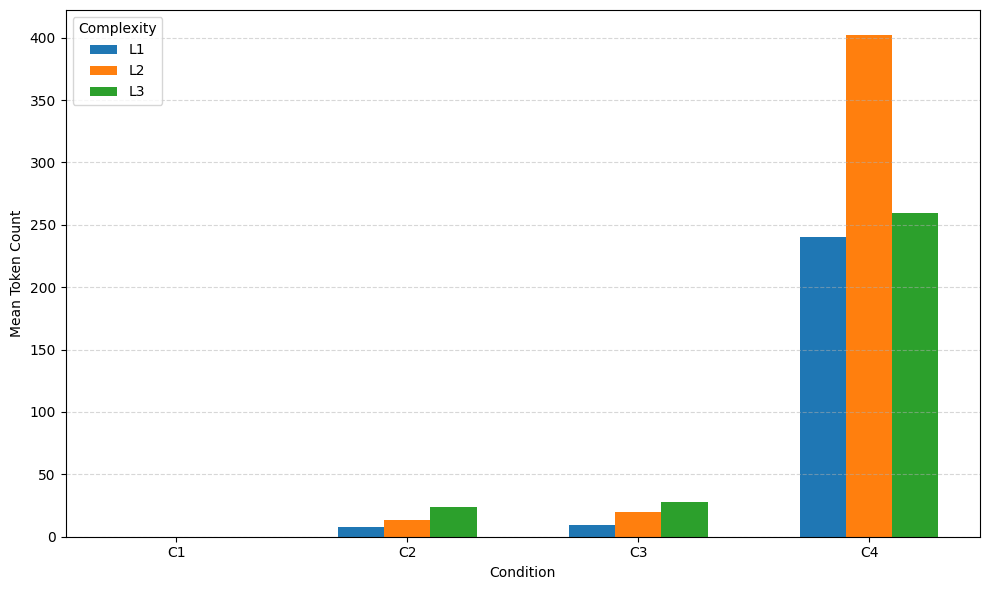

In [71]:
plot_df = all_time_summary_large.reset_index().copy()
plot_df["mean"] = plot_df["mean"].astype(float)

pivot_mean = plot_df.pivot(index="condition", columns="complexity", values="mean")

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot_mean.index))
width = 0.2

for i, complexity in enumerate(pivot_mean.columns):
    ax.bar(x + i * width, pivot_mean[complexity], width, label=complexity)

ax.set_xticks(x + width * (len(pivot_mean.columns) - 1) / 2)
ax.set_xticklabels(pivot_mean.index)
ax.set_xlabel("Condition")
ax.set_ylabel("Mean Token Count")
ax.legend(title="Complexity")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## statistischer Hypothesentest mit ANOVA

In [72]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

In [73]:
model = ols(
    "f1_exact ~ C(condition) * C(complexity)",
    data=df_A_gemini[df_A_gemini["f1_exact"].notnull()],
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_A_gemini["doc_id"]},
)
residuals = model.resid

# shapiro-wilk Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk-Test auf Normalverteilung: p-Wert = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("-> Residuen sind annähernd normalverteilt (p > 0.05).")
else:
    print("-> WARNUNG: Normalverteilung verletzt (p <= 0.05).")

Shapiro-Wilk-Test auf Normalverteilung: p-Wert = 0.0000
-> WARNUNG: Normalverteilung verletzt (p <= 0.05).


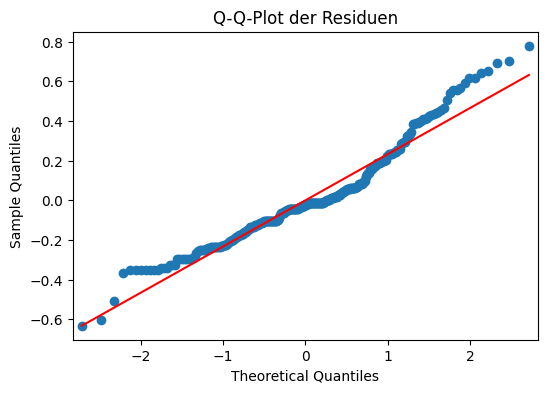

In [74]:
fig, ax = plt.subplots(figsize=(6, 4))
sm.qqplot(residuals, line="s", ax=ax)
ax.set_title("Q-Q-Plot der Residuen")
plt.show()

In [75]:
df_clean_f1 = df_A_gemini[df_A_gemini["f1_exact"].notnull()]

In [76]:
groups = [
    group["f1_exact"].values
    for name, group in df_A_gemini.groupby(["condition", "complexity"])
]
levene_stat, levene_p = stats.levene(*groups)

print(f"\nLevene-Test auf Varianzhomogenität: p-Wert = {levene_p:.4f}")
if levene_p > 0.05:
    print("-> Varianzen sind homogen (p > 0.05).")
else:
    print("-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).")


Levene-Test auf Varianzhomogenität: p-Wert = 0.0000
-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).


1. Umgang mit der verletzten Varianzhomogenität (Levene-Test)Dein Levene-Test ist hochsignifikant ($p = 0.0000$), die Varianzen sind also heterogen. Eine Standard-ANOVA würde nun den Fehler 1. Art (Alpha-Fehler) künstlich aufblähen – sie würde also signifikante Ergebnisse anzeigen, wo vielleicht gar keine sind.Die Lösung: Du nutzt robuste Standardfehler, genauer gesagt den HC3-Schätzer (Heteroskedasticity-Consistent Covariance Matrix). HC3 korrigiert die Standardfehler, sodass deine p-Werte wieder verlässlich werden, selbst wenn die Varianzen extrem streuen.Zitierfähige Quellen für deine Arbeit:Long & Ervin (2000): Using Heteroscedasticity Consistent Standard Errors in the Linear Regression Model. The American Statistician.Kernaussage für deine Arbeit: Die Autoren zeigen, dass der HC3-Schätzer bei Heteroskedastizität die beste Wahl ist, um die statistische Power aufrechtzuerhalten, insbesondere bei Stichproben unter $N = 250$.Hayes & Cai (2007): Using heteroskedasticity-consistent standard error estimators in OLS regression: An introduction and software implementation. Behavior Research Methods.Kernaussage für deine Arbeit: Sie empfehlen Forschern ausdrücklich, bei verletzter Homoskedastizität standardmäßig HC3-Schätzer zu verwenden, anstatt non-parametrische Tests auszuweichen.In Python (statsmodels) setzt du das übrigens so um:Pythonmodel = ols("f1_exact ~ C(condition) * C(complexity)", data=df).fit(cov_type='HC3')
anova_table = sm.stats.anova_lm(model, typ=2, robust="hc3")
2. Umgang mit der verletzten Normalverteilung (Shapiro-Wilk)Dein Shapiro-Wilk-Test schlägt ebenfalls an ($p = 0.0000$). Hier ist es wichtig zu verstehen: HC3 repariert nicht die fehlende Normalverteilung.Aber das ist für eine ANOVA oft gar kein großes Problem. Die ANOVA setzt voraus, dass die Residuen normalverteilt sind. Dank des Zentralen Grenzwertsatzes (Central Limit Theorem) ist das lineare Modell (OLS) jedoch extrem robust gegenüber Verletzungen der Normalverteilung, solange deine Stichprobe groß genug ist.Zitierfähige Quelle für deine Arbeit:Lumley et al. (2002): The importance of the normality assumption in large public health data sets. Annual Review of Public Health.Kernaussage für deine Arbeit: Lumley und Kollegen räumen mit dem Mythos auf, dass lineare Modelle zwingend eine Normalverteilung brauchen. Sie zeigen, dass bei ausreichend großen Stichproben (als Faustregel gelten oft $N > 30$ pro Subgruppe) die Verletzung der Normalverteilungsannahme kaum noch Auswirkungen auf die Validität der p-Werte hat.

In [ ]:
model = ols(
    "f1_exact ~ C(condition) * C(complexity)",
    data=df_A_gemini[df_A_gemini["f1_exact"].notnull()],
).fit(cov_type="cluster", cov_kwds={"groups": df_A_gemini["doc_id"]})
# cov_type zeigt auf, dass die Freiheitsgrade nicht überschätzt werden und jedes Dokument mehrmals durch die Bedingungen gelaufen ist.

anova_table_robust = sm.stats.anova_lm(model, typ=2, robust="HC3")

ss_res = anova_table_robust.loc["Residual", "sum_sq"]
anova_table_robust["partielles η²"] = (
    (anova_table_robust["sum_sq"] / (anova_table_robust["sum_sq"] + ss_res))
    .round(3)
)

anova_table_robust.columns = ["Quadratsumme", "df", "F", "p (Pr > F)", "partielles η²"]
anova_table_robust.index = [
    "Bedingung (Condition)", 
    "Komplexität (Complexity)", 
    "Wechselwirkung (Condition x Complexity)", 
    "Residuen (Fehler)"
]

anova_table_robust["Quadratsumme"] = anova_table_robust["Quadratsumme"].round(2)
anova_table_robust["F"] = anova_table_robust["F"].round(2)
anova_table_robust["df"] = anova_table_robust["df"].astype(int)
anova_table_robust["p (Pr > F)"] = anova_table_robust["p (Pr > F)"].apply(
    lambda x: (
        "" if pd.isna(x) else ("< 0,001" if x < 0.001 else f"{x:.3f}".replace(".", ","))
    )
)

anova_table_robust.loc["Residuen (Fehler)", "partielles η²"] = np.nan

for col in ["Quadratsumme", "F", "partielles η²"]:
    anova_table_robust[col] = anova_table_robust[col].apply(
        lambda x: "" if pd.isna(x) else f"{x}".replace(".", ",")
    )

print("Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):")
anova_table_robust.to_csv("./tables/anova_h3_f1_exac.csv", index=True, sep=";", decimal=",")
display(anova_table_robust)

Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):


,Quadratsumme,df,F,p (Pr > F),partielles η²
Bedingung (Condition),"11,75",3,"69,34","< 0,001","0,419"
Komplexität (Complexity),"12,19",2,"107,9","< 0,001","0,428"
Wechselwirkung (Condition x Complexity),"1,74",6,"5,14","< 0,001","0,097"
Residuen (Fehler),"16,27",288,,,


=> Signfikanter Effekt

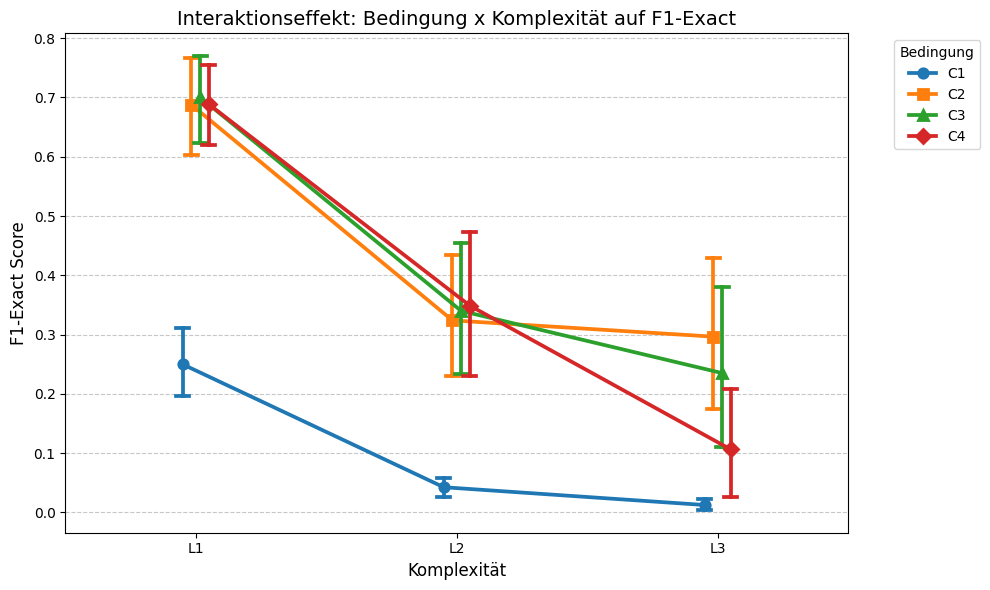

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))


sns.pointplot(
    data=df_clean_f1,
    x="complexity",
    y="f1_exact",
    hue="condition",
    dodge=True,
    markers=[
        "o",
        "s",
        "^",
        "D",
    ],
    capsize=0.05,
)

plt.title("Interaktionseffekt: Bedingung x Komplexität auf F1-Exact", fontsize=14)
plt.xlabel("Komplexität", fontsize=12)
plt.ylabel("F1-Exact Score", fontsize=12)

plt.legend(title="Bedingung", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [108]:
import pingouin as pg

post_hoc_results = pg.pairwise_gameshowell(
    data=df_clean_f1, dv="f1_exact", between="condition"
)

print("Ergebnisse des Post-Hoc Games-Howell Test zu paarweisen Vergleiche:")
post_hoc_de = post_hoc_results.round(3).astype(str).map(lambda x: x.replace(".", ","))
display(post_hoc_de)

Ergebnisse des Post-Hoc Games-Howell Test zu paarweisen Vergleiche:


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,C1,C2,"0,102","0,436","-0,334","0,041","-8,077","99,502","0,0","-1,312"
1,C1,C3,"0,102","0,425","-0,323","0,042","-7,716","98,81","0,0","-1,254"
2,C1,C4,"0,102","0,381","-0,28","0,043","-6,474","97,243","0,0","-1,052"
3,C2,C3,"0,436","0,425","0,011","0,054","0,201","147,968","0,997","0,033"
4,C2,C4,"0,436","0,381","0,055","0,055","0,991","147,644","0,755","0,161"
5,C3,C4,"0,425","0,381","0,044","0,056","0,788","147,824","0,86","0,128"


=> Der paarweise Vergleich zeigt folgende Ergebnisse:

- Die Basisbedingung C1 liefert signifikant schlechtere Ergebnisse bei der Extraktionsgenauigkeit als die KI Architekturen.  
- Der Games Howell Test belegt einen substanziellen Leistungsunterschied zwischen der regelbasierten Automatisierung und den drei verbleibenden Systemen.  
- Ein direkter Vergleich zwischen dem Single Prompt Ansatz C2, dem Single Agenten C3 und dem Multi Agenten System C4 zeigt keine statistisch signifikanten Unterschiede beim F1 Score.  
- Die Wahl der spezifischen Architektur hat keinen praktisch relevanten Einfluss auf die Ergebnisqualität über alle Komplexitätsstufen hinweg.  
- Die erste Hypothese H1 muss teilweise verworfen werden, da der postulierte Qualitätsvorsprung des Multi Agenten Systems ausbleibt.  Deskriptive Daten zeigen zwar minimale Tendenzen zugunsten der komplexeren Agenten bei hochkomplexen Fällen, diese erreichen jedoch keine inferenzstatistische Signifikanz.  
- Folglich rückt nun die vierte Forschungsfrage in den Fokus, welche die API Kosten sowie die Latenzzeiten der Architekturen evaluiert.  
- Es muss zwingend geprüft werden, ob die fehlende Leistungssteigerung der Agenten durch höhere Betriebskosten in der Praxis bestraft wird.  

### Prüfung der Auswirkung von Metadaten der Leistungsstufen auf die abhängigen Variablen

In [97]:
df_experiment = pd.read_json(
    "../data/processed/corpus_experiment_A_internal.jsonl", lines=True
)

df_experiment.columns

Index(['id', 'content', 'complexity', 'target_fields', 'ground_truth',
       'schema_class', 'metadata', 'pdf_path', 'source'],
      dtype='str')

In [95]:
df_experiment.metadata

0     {'word_count': 300, 'char_count': 2068, 'annot...
1     {'word_count': 294, 'char_count': 1958, 'annot...
2     {'word_count': 339, 'char_count': 2113, 'annot...
3     {'word_count': 483, 'char_count': 2984, 'annot...
4     {'word_count': 195, 'char_count': 1166, 'annot...
                            ...                        
70    {'word_count': 1997, 'char_count': 11380, 'ann...
71    {'word_count': 995, 'char_count': 6120, 'annot...
72    {'word_count': 5911, 'char_count': 38314, 'ann...
73    {'word_count': 1637, 'char_count': 10196, 'ann...
74    {'word_count': 1400, 'char_count': 8432, 'anno...
Name: metadata, Length: 75, dtype: object

In [98]:
df_experiment["word_count"] = df_experiment["metadata"].apply(
    lambda x: x.get("word_count")
)

df_A_gemini_with_wordcount = pd.merge(
    left=df_A_gemini,
    right=df_experiment[["id", "word_count"]],
    left_on="doc_id",
    right_on="id",
    how="inner",
)
df_A_gemini_with_wordcount.columns

Index(['condition', 'complexity', 'doc_id', 'f1_exact', 'prec_exact',
       'rec_exact', 'f1_substring', 'prec_substring', 'rec_substring',
       'f1_fuzzy', 'prec_fuzzy', 'rec_fuzzy', 'is_hallucination',
       'is_numeric_hallucination', 'is_text_hallucination', 'input_tokens',
       'output_tokens', 'all_tokens', 'retries_used', 'duration_seconds',
       'match_results_fields', 'match_results_line_items', 'ground_truth',
       'predicted', 'model', 'status', 'error_message', 'id', 'word_count'],
      dtype='str')

In [104]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model_with_wordcount = ols(
    "f1_exact ~ C(condition) + C(complexity) + word_count",
    data=df_A_gemini_with_wordcount,
).fit()
result_with_wordcount = sm.stats.anova_lm(model_with_wordcount, typ=2)
display(result_with_wordcount)

,sum_sq,df,F,PR(>F)
C(condition),5.617306,3.0,32.121520,5.579092e-18
C(complexity),8.552238,2.0,73.356575,1.485188e-26
word_count,0.100987,1.0,1.732434,1.891291e-01
Residual,17.079627,293.0,NaN,NaN


=> Die Prüfung zeigt, dass die Wortanzahl keinen statistisch signifikanten Effekt auf den exakten F1 Score hat. Die Hypothese, dass die reine Wortzahl eines Dokuments eine Auswirkung auf den F1 Wert hat, ist damit abgelehnt.

In [ ]:
df_llm_only = df_A_gemini[
    (df_A_gemini["condition"] != "C1") & (df_A_gemini["f1_fuzzy"].notnull())
]

model_llm = ols("f1_exact ~ C(condition) * C(complexity)", data=df_llm_only).fit()
residuals_llm = model_llm.resid

shapiro_stat, shapiro_p = stats.shapiro(residuals_llm)
print(f"Shapiro-Wilk-Test (nur KI-Systeme): p-Wert = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("-> Residuen sind normalverteilt (p > 0.05).")
else:
    print("-> WARNUNG: Normalverteilung verletzt (p <= 0.05).")

Shapiro-Wilk-Test (nur KI-Systeme): p-Wert = 0.0000
-> WARNUNG: Normalverteilung verletzt (p <= 0.05).


In [ ]:
groups_llm = [
    group["f1_fuzzy"].values
    for name, group in df_llm_only.groupby(["condition", "complexity"])
]
levene_stat, levene_p = stats.levene(*groups_llm)

print(f"\nLevene-Test (nur KI-Systeme): p-Wert = {levene_p:.4f}")
if levene_p > 0.05:
    print("-> Varianzen sind homogen (p > 0.05).")
else:
    print("-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).")


Levene-Test (nur KI-Systeme): p-Wert = 0.0002
-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "f1_exact ~ C(condition) * C(complexity)",
    data=df_A_gemini[(df_A_gemini["condition"] != "C1") & (df_A_gemini["f1_fuzzy"].notnull()) ],
).fit()

anova_table_robust_llms = sm.stats.anova_lm(model, typ=2, robust="HC3")

print("Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):")
display(anova_table_robust_llms)

Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):


,sum_sq,df,F,PR(>F)
C(condition),0.090224,2.0,0.622015,5.378203e-01
C(complexity),12.940104,2.0,89.210996,5.717472e-29
C(condition):C(complexity),0.323522,4.0,1.115206,3.502347e-01
Residual,15.665459,216.0,NaN,NaN


## Business Impact Analyse

In [109]:
def calculate_cost_of_pass(df):
    # Binarisierung der Erfolgswahrscheinlichkeit
    df["is_success"] = (df["f1_exact"] >= 0.90).astype(int)

    # Vermeidung von Division durch Null via Laplace Smoothing
    df["success_prob"] = df["is_success"].replace(0, 0.01)

    # Berechnung der erwarteten Korrekturkosten durch eine Fachkraft mit im Schnitt 4.47 USD pro Dokument
    df["correction_cost"] = df["f1_exact"].rsub(1.0) * 4.47

    # Tokenkosten für Gemini 3.5 Flash:
    # Input:  1.50 USD / 1.000.000 Tokens = 0.0000015 USD
    # Output: 9.00 USD / 1.000.000 Tokens = 0.0000090 USD
    df["token_cost"] = (df["input_tokens"] * 0.0000015) + (
        df["output_tokens"] * 0.000009
    )

    # Latenzkosten via Cloud Instanz Stundensatz exemplarisch 0.50 USD pro Stunde
    df["latency_cost"] = df["duration_seconds"] * (0.50 / 3600.0)

    # Gesamtkosten pro Versuch
    df["total_cost_per_try"] = (
        df["token_cost"] + df["latency_cost"] + df["correction_cost"]
    )

    # Cost of Pass
    df["cost_of_pass"] = df["total_cost_per_try"] / df["success_prob"]

    return df

In [110]:
df_A_gemini = calculate_cost_of_pass(df_A_gemini)

In [112]:
df_A_gemini["log_cost_of_pass"] = np.log(df_A_gemini["cost_of_pass"])

In [113]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

model = ols("log_cost_of_pass ~ C(condition) + C(complexity)", data=df_A_gemini).fit()
residuals = model.resid
fitted_vals = model.fittedvalues

# Keine Multikollinearitaet via VIF
X = model.model.exog
vif_data = pd.DataFrame()
vif_data["Variable"] = model.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print(vif_data)

# Exogenitaet der unabhaengigen Variablen
mean_residuals = np.mean(residuals)
print(f"Mittelwert der Residuen: {mean_residuals:.4f} Sollte nahe 0 sein")

# Homoskedastizitaet der Residuen via Breusch Pagan Test
bp_test = het_breuschpagan(residuals, X)
print(f"Breusch Pagan p Wert: {bp_test[1]:.4f}")

# Normalverteilung der Residuen via Shapiro Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro Wilk p Wert: {shapiro_p:.4f}")

# Skalenniveau der abhaengigen Variable
# Die Variable cost_of_pass ist metrisch und kontinuierlich.

# Keine einflussreichen Faelle via Cooks Distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
outliers = sum(cooks_d > (4 / len(df_A_gemini)))
print(f"Anzahl kritischer Ausreisser nach Cooks Distance: {outliers}")

# Keine Autokorrelation via Durbin Watson Test
dw_stat = durbin_watson(residuals)
print(f"Durbin Watson Statistik: {dw_stat:.2f} Sollte nahe 2.0 sein")

              Variable               VIF
0            Intercept 5.999999999999997
1   C(condition)[T.C2] 1.500000000000000
2   C(condition)[T.C3] 1.500000000000000
3   C(condition)[T.C4] 1.500000000000000
4  C(complexity)[T.L2] 1.333333333333333
5  C(complexity)[T.L3] 1.333333333333333
Mittelwert der Residuen: 0.0000 Sollte nahe 0 sein
Breusch Pagan p Wert: 0.0013
Shapiro Wilk p Wert: 0.0000
Anzahl kritischer Ausreisser nach Cooks Distance: 11
Durbin Watson Statistik: 1.17 Sollte nahe 2.0 sein


In [ ]:
model_robust = ols("cost_of_pass ~ C(condition) + C(complexity)", data=df_A_gemini).fit(
    cov_type="HC3"
)

In [ ]:
df_A_gemini["log_cost_of_pass"] = np.log(df_A_gemini["cost_of_pass"])